#**Employee Workload and Attrition Analysis**

* **Oscar Ivanovich Avila Chiu 35676**
* **Axel Daniel Nuño Arrieta 35859**

En este notebook se llevará a cabo un análisis integral de un conjunto de datos enfocado en la carga laboral y la rotación de empleados dentro de una organización. El proyecto seguirá un flujo de trabajo completo de ciencia de datos: desde el Análisis Exploratorio de Datos (EDA) y el Preprocesamiento, hasta el entrenamiento y evaluación de distintos modelos de aprendizaje automático, su exportación a formato ONNX y su posterior integración en una aplicación móvil desarrollada con Flutter.

El dataset contiene información relacionada con el entorno laboral de los empleados, incluyendo departamento, nivel de puesto (Junior, Mid, Senior), salario mensual, horas promedio trabajadas por semana, número de proyectos asignados, calificación de desempeño, días de ausencia y nivel de satisfacción laboral. La variable objetivo es **attrition**, que indica si el empleado abandonó la organización (Yes) o permaneció en ella (No). El objetivo principal del proyecto es analizar cómo estos factores influyen en la rotación de personal y construir un modelo capaz de predecir el riesgo de abandono a partir de estas características.

El dataset fue obtenido desde la plataforma Kaggle y se encuentra disponible en el siguiente enlace:
[https://www.kaggle.com/datasets/jayjoshi37/employee-workload-and-attrition-analysis](https://www.kaggle.com/datasets/jayjoshi37/employee-workload-and-attrition-analysis)

A continuación, iniciaremos con la importación de librerías y la carga de datos para dar el primer paso del proceso: el Análisis Exploratorio de Datos (EDA).


##**EDA**

In [2]:
import seaborn as sns
import random
import torch.nn as nn
import pandas as pd
import torch
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm

data = pd.read_csv('workload.csv')
data

,employee_id,department,role_level,monthly_salary,avg_weekly_hours,projects_handled,performance_rating,absences_days,job_satisfaction,attrition
0,1,HR,Junior,81750,55,1,1,17,1,Yes
1,2,Engineering,Senior,58140,36,2,4,13,1,Yes
2,3,Finance,Mid,37747,61,2,2,20,5,No
3,4,Finance,Senior,81993,36,4,1,17,2,Yes
4,5,Sales,Senior,45439,53,5,5,5,1,No
...,...,...,...,...,...,...,...,...,...,...
2795,2796,HR,Senior,94356,44,7,4,0,5,No
2796,2797,Finance,Senior,88087,54,7,2,14,4,No
2797,2798,Marketing,Senior,41148,60,8,3,10,1,Yes
2798,2799,Finance,Senior,47878,56,5,5,2,5,No


In [30]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

False

###**Información básica y estadística**

Se utiliza el método .info() para obtener una mejor comprensión del conjunto de datos, ya que permite identificar el número de registros no nulos y el tipo de dato correspondiente a cada columna.

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   employee_id         2800 non-null   int64 
 1   department          2800 non-null   object
 2   role_level          2800 non-null   object
 3   monthly_salary      2800 non-null   int64 
 4   avg_weekly_hours    2800 non-null   int64 
 5   projects_handled    2800 non-null   int64 
 6   performance_rating  2800 non-null   int64 
 7   absences_days       2800 non-null   int64 
 8   job_satisfaction    2800 non-null   int64 
 9   attrition           2800 non-null   object
dtypes: int64(7), object(3)
memory usage: 218.9+ KB


De manera similar, se utiliza el método .describe() para obtener estadísticas descriptivas de las variables numéricas del conjunto de datos. En este caso, el resultado se transpone con el objetivo de mejorar la legibilidad y facilitar la interpretación de los valores obtenidos.

In [5]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
employee_id,2800.0,1400.500000,808.434702,1.0,700.75,1400.5,2100.25,2800.0
monthly_salary,2800.0,74492.075000,25899.209391,30006.0,51665.00,74587.5,97249.50,119977.0
avg_weekly_hours,2800.0,49.842500,8.980976,35.0,42.00,50.0,57.00,65.0
projects_handled,2800.0,4.519286,2.286778,1.0,3.00,4.0,7.00,8.0
performance_rating,2800.0,2.960714,1.404794,1.0,2.00,3.0,4.00,5.0
absences_days,2800.0,9.995000,6.056656,0.0,5.00,10.0,15.00,20.0
job_satisfaction,2800.0,2.995357,1.414332,1.0,2.00,3.0,4.00,5.0


En total, el conjunto de datos cuenta con **10 columnas y 2,800 registros**, los cuales describen características relacionadas con la carga laboral, el desempeño y la satisfacción de los empleados dentro de una organización. Todas las columnas contienen valores no nulos, lo que facilita el proceso de análisis y modelado.

A continuación, se describen las variables incluidas en el dataset:

**Variables de Identificación**

* **employee_id**: Identificador único asignado a cada empleado.
  Esta variable cumple únicamente una función de identificación y no aporta valor predictivo, por lo que será eliminada durante el preprocesamiento.

**Variables Organizacionales y de Puesto**
* **department**: Departamento en el que trabaja el empleado (Engineering, HR, Finance, Marketing, Sales, Operations).
* **role_level**: Nivel jerárquico del empleado dentro de la organización (Junior, Mid, Senior).

Estas variables son categóricas y permiten analizar si el área o el nivel de seniority influyen en la rotación.

**Variables de Carga Laboral y Desempeño**

* **monthly_salary**: Salario mensual del empleado.
* **avg_weekly_hours**: Promedio de horas trabajadas por semana.
* **projects_handled**: Número de proyectos activos asignados al empleado.
* **performance_rating**: Evaluación anual de desempeño en una escala de 1 a 5.
* **absences_days**: Número de días de ausencia durante el año.
* **job_satisfaction**: Nivel de satisfacción laboral en una escala de 1 a 5.

Estas variables permiten estudiar la relación entre carga laboral, desempeño y bienestar del empleado, así como su posible impacto en la decisión de abandonar la organización.

**Variable Objetivo**

* **attrition**: Indica si el empleado dejó la organización (Yes) o permaneció en ella (No).

Esta es la variable que el modelo intentará predecir, planteando un problema de **clasificación binaria supervisada**.

Para el análisis y la construcción del modelo, utilizaremos **attrition** como variable objetivo. Todas las demás columnas se considerarán variables explicativas, aunque durante el preprocesamiento se eliminará `employee_id` por no aportar valor predictivo al modelo.

###**Visualización de la distribución de variables numéricas**

Las variables numéricas del dataset representan características cuantitativas relacionadas con la carga laboral, el desempeño profesional y el bienestar del empleado dentro de la organización. Estas variables pueden influir directamente en la probabilidad de rotación (attrition), ya que factores como largas jornadas laborales, alta carga de proyectos, bajo nivel de satisfacción o elevado ausentismo podrían estar asociados con una mayor probabilidad de abandono.

En este análisis se consideran tanto variables continuas como discretas que describen condiciones laborales y métricas de desempeño. Aunque la mayoría están representadas como valores enteros, todas corresponden a mediciones cuantitativas relevantes para el problema de clasificación binaria que se abordará posteriormente.

La visualización de las distribuciones permite identificar posibles asimetrías, concentraciones de valores, rangos predominantes y presencia de valores atípicos, lo cual es fundamental antes de aplicar técnicas de escalamiento o modelado.

Para ello, se utiliza la librería seaborn, generando histogramas acompañados de estimaciones de densidad (KDE) para cada variable numérica seleccionada.

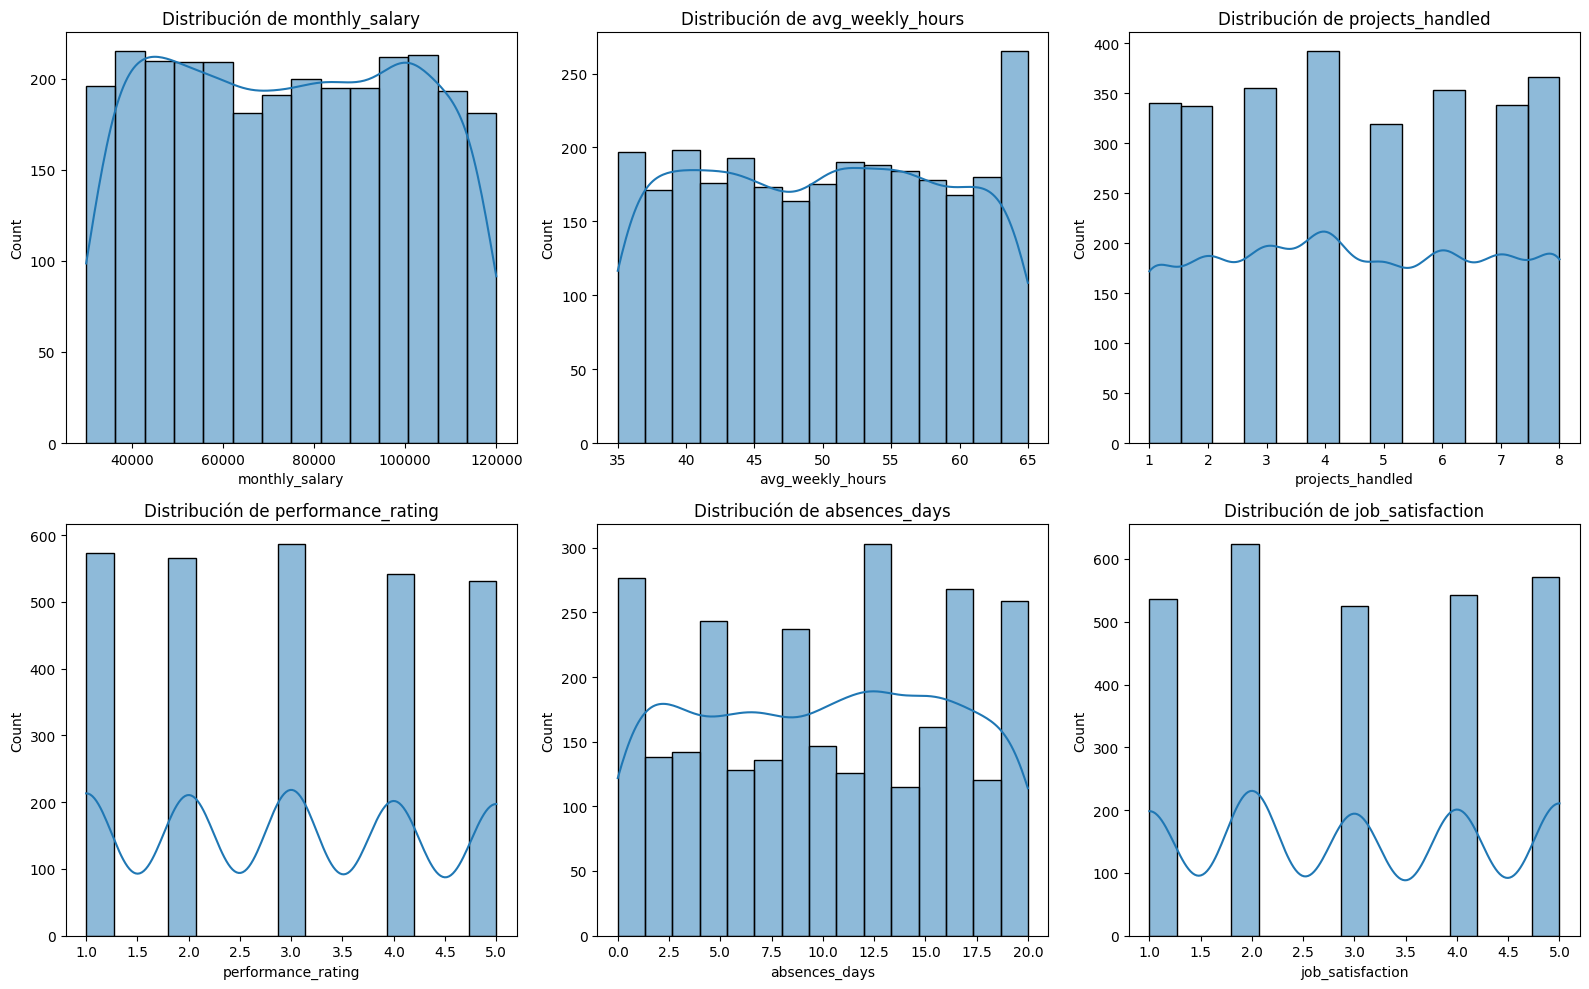

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = [
    'monthly_salary',
    'avg_weekly_hours',
    'projects_handled',
    'performance_rating',
    'absences_days',
    'job_satisfaction'
]

fig, axs = plt.subplots(2, 3, figsize=(16, 10))

for ax, col in zip(axs.ravel(), numerical_cols):
    sns.histplot(data=data[col], kde=True, ax=ax)
    ax.set_title(f'Distribución de {col}')

fig.tight_layout()
plt.show()

###**Visualización de variables categóricas**

A continuación, se visualizarán las distribuciones de las variables categóricas del conjunto de datos mediante gráficos de barras. Este tipo de visualización permite observar la frecuencia de cada categoría dentro de cada variable, lo cual es útil para identificar posibles desbalances y comprender mejor la estructura organizacional representada en el dataset.

En este caso, las variables categóricas están relacionadas con el área de trabajo y el nivel jerárquico del empleado dentro de la empresa. Estas características pueden influir en la carga laboral, la responsabilidad asumida y, potencialmente, en la probabilidad de rotación.

La columna employee_id no se incluye en este análisis, ya que es un identificador único sin valor analítico. Por otro lado, la variable attrition, aunque es categórica, será analizada de manera independiente por tratarse de la variable objetivo del modelo.

Las variables seleccionadas presentan baja cardinalidad, lo que facilita su interpretación visual y permite obtener una visión clara de cómo se distribuyen los empleados entre departamentos y niveles de puesto.

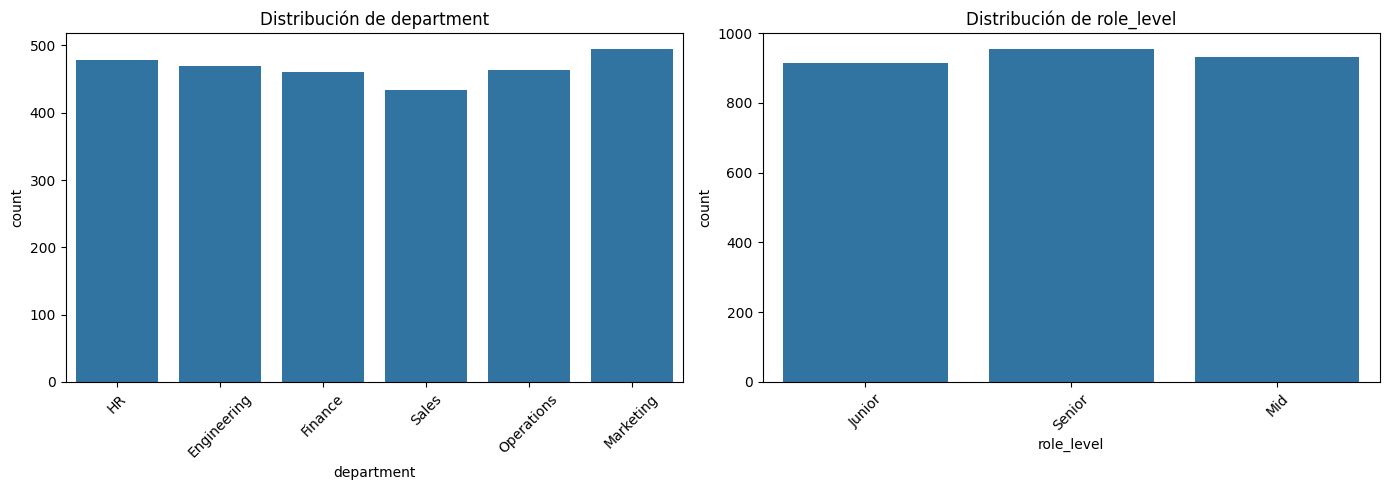

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols = [
    'department',
    'role_level'
]

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axs.ravel(), categorical_cols):
    sns.countplot(data=data, x=col, ax=ax)
    ax.set_title(f'Distribución de {col}')
    ax.tick_params(axis='x', rotation=45)

fig.tight_layout()
plt.show()


###**Distribución de la variable objetivo**

Finalmente, se visualizará la distribución de la variable objetivo attrition con el fin de comprender cómo se distribuyen los empleados que abandonaron la organización frente a aquellos que permanecieron en ella. Este análisis es fundamental en problemas de clasificación binaria, ya que permite identificar posibles desbalances entre clases, lo cual puede influir directamente en el rendimiento y la interpretación del modelo.

Dado que attrition es una variable categórica con dos posibles valores (Yes / No), se utilizará un gráfico de barras para representar la frecuencia de cada categoría. Esto permitirá evaluar si el dataset se encuentra balanceado o si será necesario considerar técnicas adicionales durante el entrenamiento del modelo (por ejemplo, ajuste de métricas o ponderación de clases).

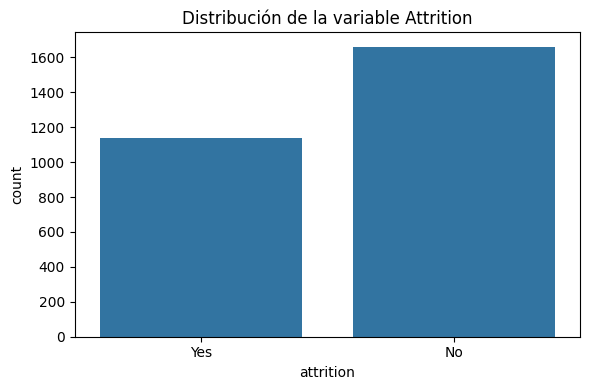

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

fig = plt.figure(figsize=(6, 4))
sns.countplot(data=data, x='attrition')
plt.title('Distribución de la variable Attrition')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


###**Relación entre variables numéricas y Attrition**

En esta sección se analizará la relación entre las variables numéricas relacionadas con la carga laboral y la variable objetivo attrition.

El objetivo es identificar si existen diferencias claras en factores como salario, horas trabajadas, número de proyectos, desempeño, ausencias o satisfacción laboral entre los empleados que abandonaron la organización y aquellos que permanecieron en ella. Este análisis permite detectar patrones que podrían ser determinantes en la predicción de la rotación.

Dado que la variable objetivo es categórica (Yes / No) y las variables explicativas son numéricas, se utilizarán diagramas de caja (boxplots) para visualizar cómo varía cada variable según el estado de attrition. Los boxplots permiten observar la mediana, dispersión y posibles valores atípicos en cada grupo.

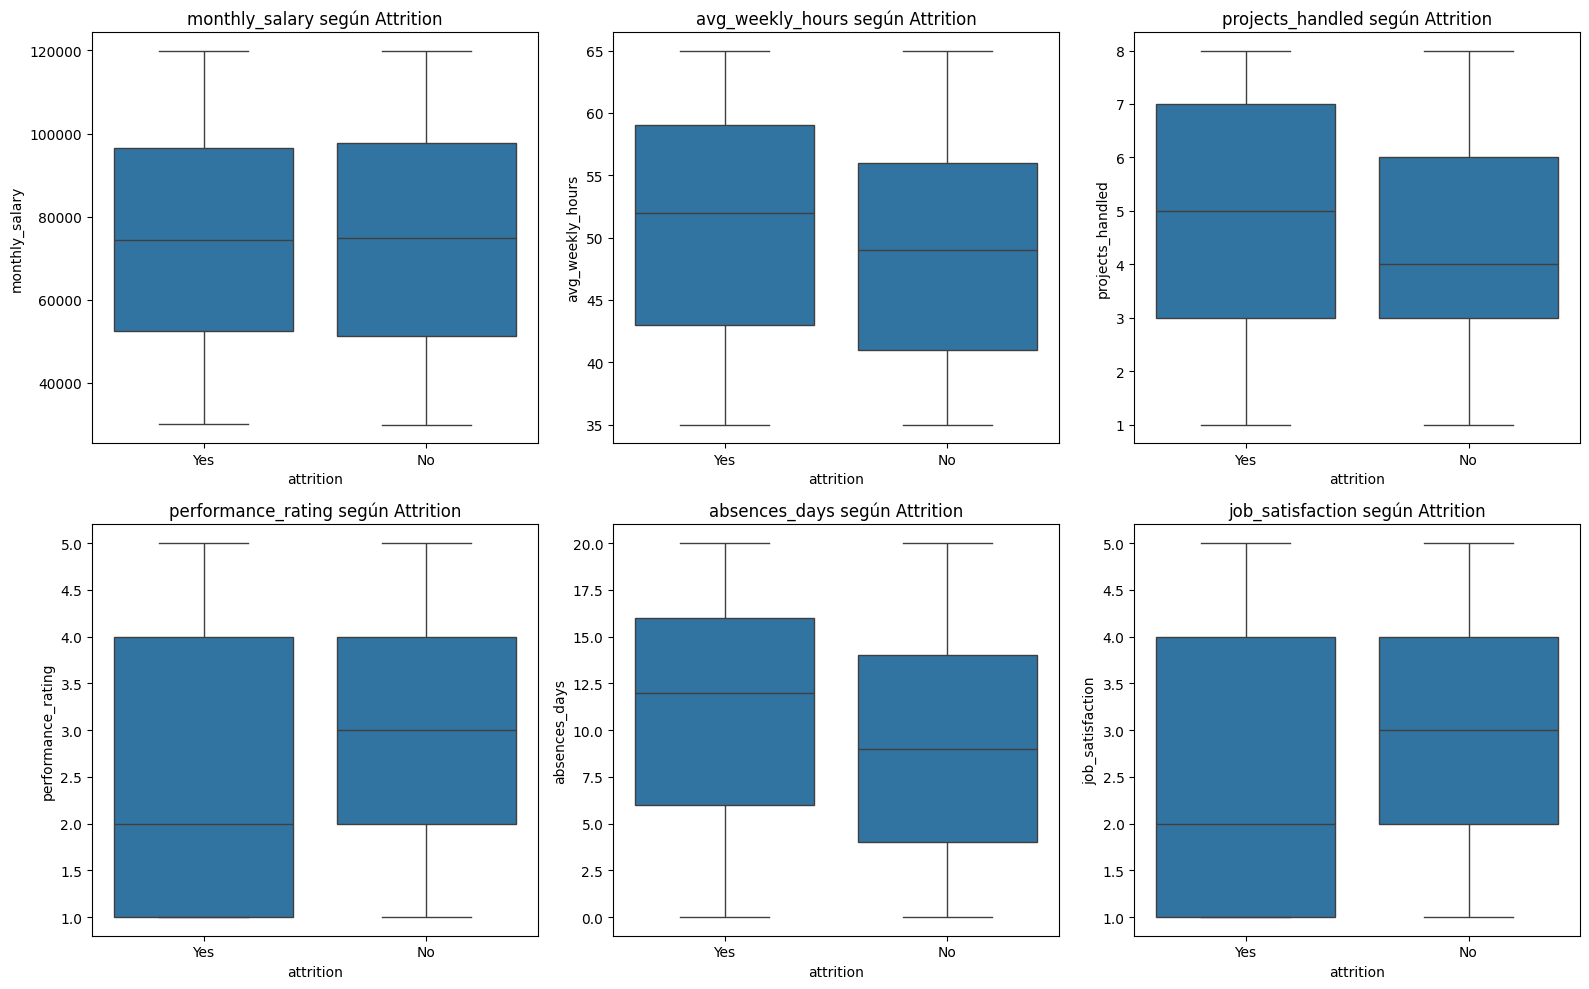

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = [
    'monthly_salary',
    'avg_weekly_hours',
    'projects_handled',
    'performance_rating',
    'absences_days',
    'job_satisfaction'
]

fig, axs = plt.subplots(2, 3, figsize=(16, 10))

for ax, col in zip(axs.ravel(), numerical_cols):
    sns.boxplot(data=data, x='attrition', y=col, ax=ax)
    ax.set_title(f'{col} según Attrition')
    ax.tick_params(axis='x', rotation=0)

fig.tight_layout()
plt.show()


El análisis mediante gráficos de caja (boxplots) permite identificar diferencias claras en el comportamiento y la satisfacción entre los empleados que permanecen en la empresa y aquellos que deciden abandonarla (attrition):
* Carga Laboral y Estrés: Los empleados que presentan rotación ("Yes") tienden a trabajar más horas, con un promedio de 52 horas semanales frente a las 49 horas de quienes permanecen. De igual forma, el número de proyectos manejados es ligeramente superior en el grupo que se va, lo que sugiere que la sobrecarga laboral es un factor de riesgo directo para el abandono.
*  Compromiso y Absentismo: Existe una diferencia notable en los días de ausencia. El personal que deja la organización promedia 12 días de ausencia al año, mientras que los que se quedan promedian 9 días. Este incremento en el absentismo suele ser un indicador temprano de desvinculación emocional o búsqueda de nuevas oportunidades.
* Satisfacción y Desempeño: La satisfacción laboral es significativamente menor en el grupo de rotación, con una mediana de 2 puntos en contraste con los 3 puntos del grupo estable. Curiosamente, el performance_rating (calificación de desempeño) también es menor en quienes se van, lo que podría indicar que la falta de motivación o el bajo rendimiento precede a la renuncia.
* Factor Económico: El salario mensual muestra distribuciones muy similares en ambos grupos, con medianas cercanas a los $75,000. Esto sugiere que, en este conjunto de datos particular, la decisión de dejar la empresa podría estar más ligada a factores de bienestar, carga de trabajo y satisfacción que a una diferencia salarial estricta.

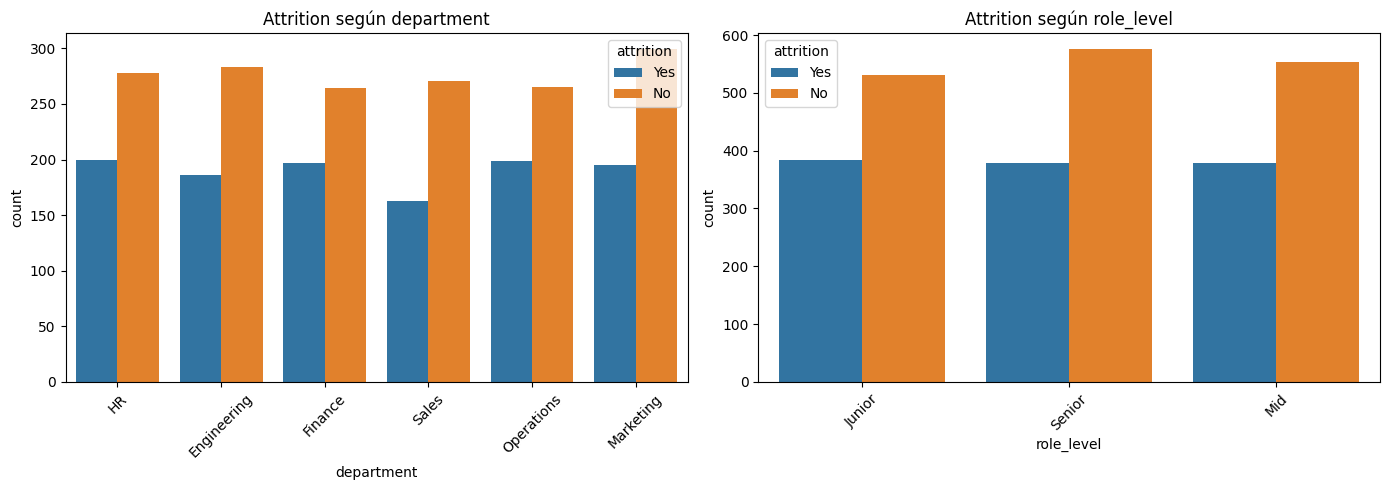

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols = [
    'department',
    'role_level'
]

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axs.ravel(), categorical_cols):
    sns.countplot(
        data=data,
        x=col,
        hue='attrition',
        ax=ax
    )
    ax.set_title(f'Attrition según {col}')
    ax.tick_params(axis='x', rotation=45)

fig.tight_layout()
plt.show()

El análisis visual de las categorías de empleo permite identificar en qué áreas y niveles jerárquicos se concentra la mayor fuga de talento:

* Distribución por Departamento: Se observa que la rotación no es uniforme en toda la empresa. Los departamentos de HR (Recursos Humanos) y Operations presentan el mayor volumen de empleados que han dejado la organización ("Yes"), seguidos muy de cerca por Finance y Marketing. En contraste, el departamento de Sales muestra la menor cantidad de salidas en términos absolutos, lo que sugiere una mayor estabilidad o una dinámica de retención más efectiva en esa área específica.
* Impacto del Nivel Jerárquico (Role Level): Al analizar el nivel de antigüedad, resalta que los perfiles Junior son los que presentan la tasa de rotación más alta en comparación con su contraparte que permanece en la empresa. Aunque los niveles Senior y Mid también registran salidas, la brecha entre los que se quedan y los que se van es más estrecha en el nivel Junior. Esto indica que los empleados en etapas tempranas de su carrera dentro de la organización tienen una mayor propensión a abandonar su puesto, posiblemente en busca de crecimiento externo o debido a una menor adaptación a la cultura corporativa.

###**Matriz de correlación entre variables numéricas**
En esta sección se analizará la relación lineal entre las variables numéricas del conjunto de datos mediante una matriz de correlación.

El objetivo es identificar posibles relaciones fuertes entre variables relacionadas con la carga laboral, desempeño y satisfacción del empleado, así como detectar multicolinealidad, la cual podría afectar el rendimiento de ciertos modelos de clasificación (por ejemplo, regresión logística).

La correlación toma valores entre -1 y 1, donde:

* Valores cercanos a 1 → relación positiva fuerte
* Valores cercanos a -1 → relación negativa fuerte
* Valores cercanos a 0 → poca o ninguna relación lineal

Este análisis es útil para comprender cómo se relacionan factores como salario, horas trabajadas, número de proyectos, ausencias y satisfacción laboral.

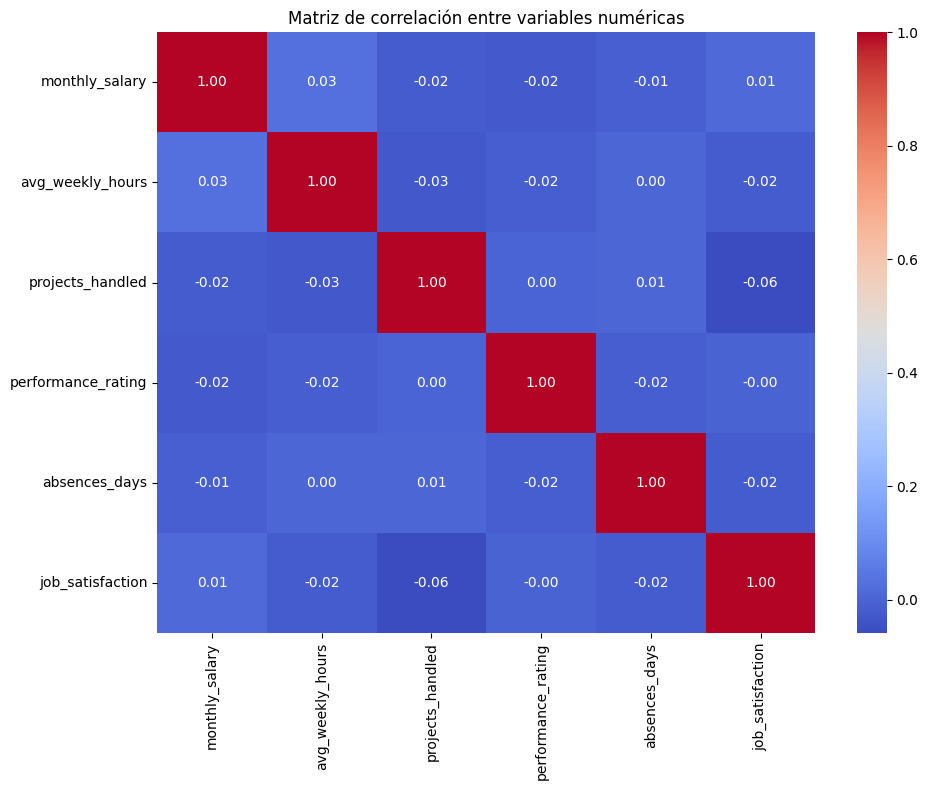

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = [
    'monthly_salary',
    'avg_weekly_hours',
    'projects_handled',
    'performance_rating',
    'absences_days',
    'job_satisfaction'
]

corr_matrix = data[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlación entre variables numéricas')
plt.tight_layout()
plt.show()


Al examinar la relación entre las variables numéricas y la distribución organizacional, se identifican patrones clave que definen el entorno laboral de la empresa:
* Independencia de las Variables Numéricas: La matriz de correlación muestra coeficientes extremadamente bajos (cercanos a 0.00) entre la mayoría de las variables como salario, horas semanales, proyectos y satisfacción. Esto indica que factores como la sobrecarga de proyectos o las horas trabajadas no están necesariamente vinculados al nivel salarial en este conjunto de datos. Esta independencia es positiva para el modelado, ya que reduce problemas de multicolinealidad.


###**Tratamiento de valores perdidos**
Antes de construir los pipelines de preprocesamiento, es importante verificar la presencia de valores faltantes en el conjunto de datos. La identificación de valores nulos permite definir estrategias de imputación si fuese necesario y evita problemas durante el entrenamiento del modelo.

En este dataset, todas las columnas relevantes (department, role_level, monthly_salary, avg_weekly_hours, projects_handled, performance_rating, absences_days, job_satisfaction, attrition) no presentan valores faltantes, por lo que no será necesaria ninguna imputación. Sin embargo, esta verificación es una buena práctica para asegurar la integridad del conjunto de datos.

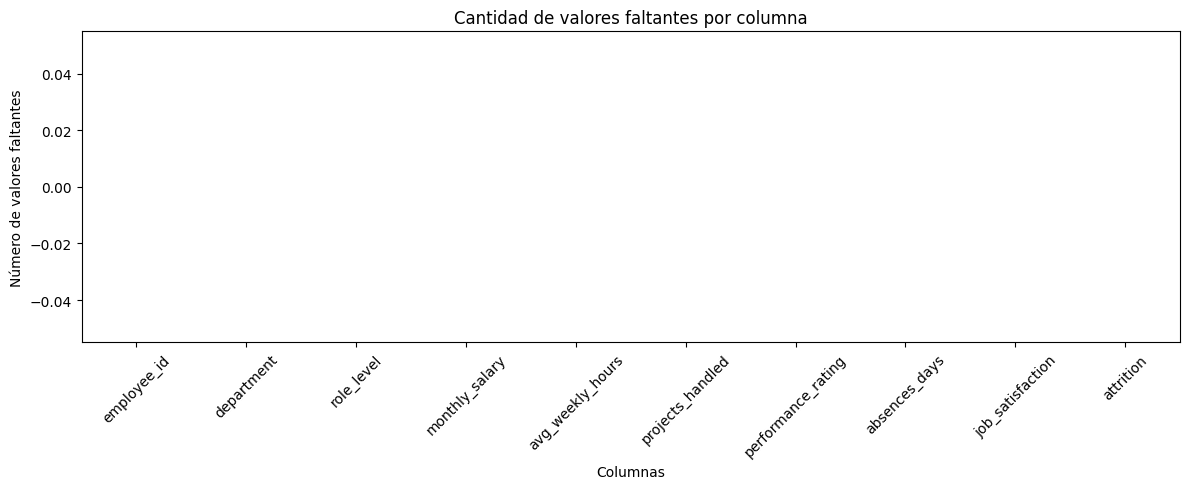

In [12]:
import matplotlib.pyplot as plt

missing_counts = data.isnull().sum()

plt.figure(figsize=(12, 5))
missing_counts.plot(kind='bar')
plt.title('Cantidad de valores faltantes por columna')
plt.xlabel('Columnas')
plt.ylabel('Número de valores faltantes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


También se puede calcular el porcentaje de los valores faltantes para cada columna, para entender mejor la información faltante.

In [13]:
missing_percent = data.isnull().mean() * 100
missing_percent.sort_values(ascending=False)

,0
employee_id,0.0
department,0.0
role_level,0.0
monthly_salary,0.0
avg_weekly_hours,0.0
projects_handled,0.0
performance_rating,0.0
absences_days,0.0
job_satisfaction,0.0
attrition,0.0


Al evaluar la calidad del conjunto de datos para este proyecto, se observa una integridad perfecta en todas las dimensiones analizadas. Cada una de las columnas presenta un 0.0% de valores nulos, lo que significa que los 2,800 registros están completamente cumplimentados.

Esta ausencia de datos faltantes incluye tanto las variables de identificación y organizacionales (department, role_level) como los indicadores métricos de desempeño y carga laboral (avg_weekly_hours, projects_handled, monthly_salary). Lo más importante es que la variable objetivo, attrition, también se encuentra íntegra, lo que garantiza una base sumamente robusta para las etapas de análisis y el posterior entrenamiento del modelo de clasificación.

##**Preprocesamiento Pipeline**
Ahora que hemos analizado el conjunto de datos y comprendido las relaciones entre la carga laboral, el desempeño y la rotación de empleados, podemos proceder a construir los pipelines de preprocesamiento para las variables numéricas y categóricas.

El uso de pipelines permite aplicar transformaciones de manera estructurada, reproducible y sin fugas de información (data leakage), lo cual es fundamental antes de entrenar modelos de clasificación. Además, garantiza que las mismas transformaciones aplicadas al conjunto de entrenamiento se utilicen posteriormente en el conjunto de prueba y durante la integración del modelo en la aplicación móvil.

En este problema de clasificación binaria (predicción de attrition), tenemos:

* Variables numéricas:
monthly_salary, avg_weekly_hours, projects_handled,
performance_rating, absences_days, job_satisfaction

* Variables categóricas:
department, role_level

Para este propósito, utilizamos ColumnTransformer, que permite aplicar diferentes transformaciones a distintos subconjuntos de columnas. Cada transformación se define como un pipeline independiente mediante Pipeline.

En general:

* A las variables numéricas se les aplicará StandardScaler para normalizar la escala.

* A las variables categóricas se les aplicará OneHotEncoder para convertirlas en variables numéricas sin introducir un orden artificial.


###**Transformaciones definidas**
**Variables numéricas**
Incluyen características relacionadas con carga laboral, desempeño y bienestar del empleado:

* monthly_salary
* avg_weekly_hours
* projects_handled
* performance_rating
* absences_days
* job_satisfaction

En este dataset no se presentan valores faltantes en estas variables, por lo que no será necesaria una imputación previa.

Posteriormente, todas las variables numéricas serán escaladas utilizando StandardScaler, ya que algunos modelos como Regresión Logística, SVM o KNN son sensibles a la magnitud de las variables. El escalado permite que todas las características contribuyan de manera equilibrada al entrenamiento del modelo.


**Variables categóricas**

Incluyen características organizacionales y jerárquicas:

* department
* role_level

Estas variables no presentan valores faltantes. Sin embargo, para garantizar robustez del pipeline en escenarios futuros, pueden imputarse con la categoría más frecuente si fuese necesario.

Posteriormente, se transformarán mediante OneHotEncoder, lo que permitirá convertirlas en variables numéricas binarias sin introducir un orden artificial entre categorías. Esto es fundamental para que los modelos de clasificación puedan interpretarlas correctamente.

**Variables excluidas**
* employee_id se eliminará por no aportar valor predictivo (es únicamente un identificador).
* attrition no se incluye en el pipeline, ya que corresponde a la variable objetivo que el modelo intentará predecir.

In [19]:
import pandas as pd
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset

numerical_cols = [
    'monthly_salary',
    'avg_weekly_hours',
    'projects_handled',
    'performance_rating',
    'absences_days',
    'job_satisfaction'
]

categorical_cols = [
    'department',
    'role_level'
]

df = data.copy()

df['attrition'] = df['attrition'].map({'Yes': 1, 'No': 0})

X = df[numerical_cols + categorical_cols]
y = df['attrition']

###**Definición de variables y división del conjunto de datos**

Ahora procedemos a definir la matriz de características X y el vector objetivo y, así como a dividir el conjunto de datos en entrenamiento y prueba. Utilizaremos una partición 80–10-10, donde el 80 % de los datos se empleará para entrenar el modelo y el 10 % restante para validar y evaluarlo.

En nuestro caso, la variable objetivo será attrition, ya que representa si el empleado abandonó la organización (Yes) o permaneció en ella (No).

Las variables explicativas incluyen tanto características numéricas como categóricas previamente analizadas:

Numéricas:
* monthly_salary
* avg_weekly_hours
* projects_handled
* performance_rating
* absences_days
* job_satisfaction

Categóricas:
* department
* role_level

Es importante destacar que attrition se excluye de la matriz de características para evitar fuga de información (data leakage), ya que es la variable que el modelo intentará predecir.

In [26]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

X_train = pd.get_dummies(X_train, columns=categorical_cols)
X_val = pd.get_dummies(X_val, columns=categorical_cols)
X_test = pd.get_dummies(X_test, columns=categorical_cols)

X_train, X_val = X_train.align(X_val, join='left', axis=1, fill_value=0)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

mean = torch.tensor(X_train[numerical_cols].mean().values, dtype=torch.float32)
std = torch.tensor(X_train[numerical_cols].std().values, dtype=torch.float32)

num_numerical = len(numerical_cols)

class Preprocessor(nn.Module):
    def __init__(self, mean, std, num_numerical):
        super().__init__()
        self.register_buffer('mean', mean)
        self.register_buffer('std', std)
        self.num_numerical = num_numerical

    def forward(self, x):
        x_num = x[:, :self.num_numerical]
        x_cat = x[:, self.num_numerical:]
        x_num = (x_num - self.mean) / (self.std + 1e-8)
        return torch.cat([x_num, x_cat], dim=1)

class EmployeeDataset(Dataset):
    def __init__(self, X, y):
        X = X.astype('float32')
        y = y.astype('float32')

        self.X = torch.tensor(X.values, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = EmployeeDataset(X_train, y_train)
val_dataset = EmployeeDataset(X_val, y_val)
test_dataset = EmployeeDataset(X_test, y_test)

print("Lenght train:", len(train_dataset))
print("Lenght val:",len(val_dataset))
print("Lenght test:",len(test_dataset))

Lenght train: 2240
Lenght val: 280
Lenght test: 280


In [32]:
from torch.utils.data import DataLoader

batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Dado que se trata de un problema de clasificación, verificamos que la distribución de las clases sea similar en los conjuntos mediante gráficos de conteo.

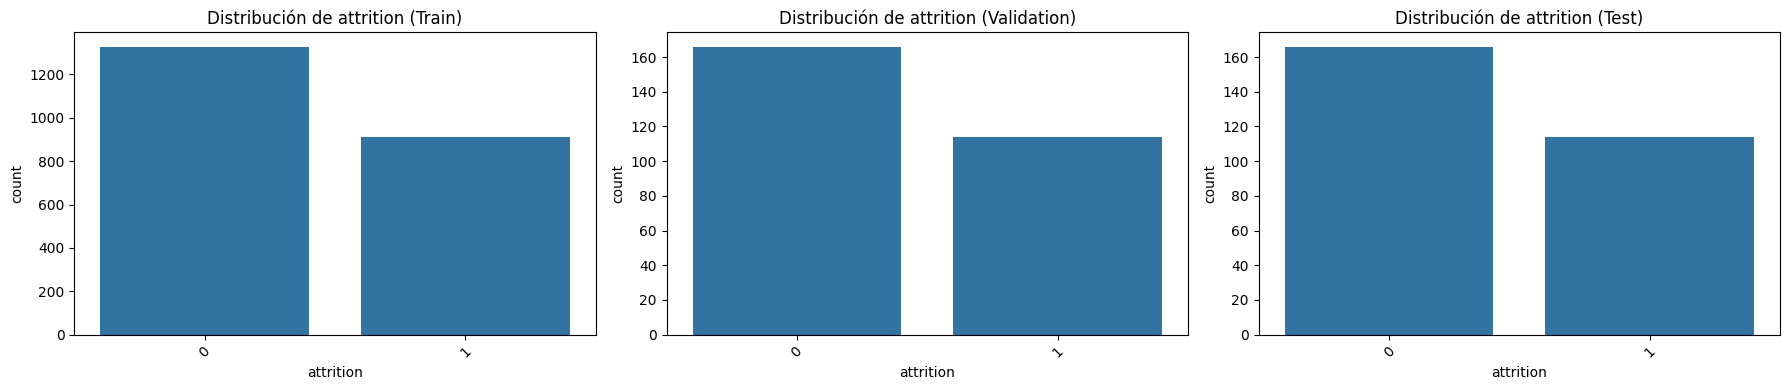

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(1, 3, figsize=(18, 4))

sns.countplot(x=y_train, ax=axs[0])
axs[0].set_title('Distribución de attrition (Train)')
axs[0].tick_params(axis='x', rotation=45)

sns.countplot(x=y_val, ax=axs[1])
axs[1].set_title('Distribución de attrition (Validation)')
axs[1].tick_params(axis='x', rotation=45)

sns.countplot(x=y_test, ax=axs[2])
axs[2].set_title('Distribución de attrition (Test)')
axs[2].tick_params(axis='x', rotation=45)

fig.tight_layout()
plt.show()

##**Construir Modelo Clasificación**    
La variable objetivo attrition representa si un empleado abandonó la organización (Yes) o permaneció en ella (No).

Dado que se trata de un problema de clasificación binaria y el principal interés del área de Recursos Humanos es anticipar la salida de empleados, no todos los errores tienen el mismo impacto.

El error más costoso en este contexto es el Falso Negativo:

* El empleado realmente se va (Yes)
* Pero el modelo predice que no se irá (No)

Este tipo de error impide que la empresa tome acciones preventivas.

Por esta razón, la métrica principal de evaluación será **Recall** para la clase "Yes", ya que mide:

* De todos los empleados que realmente abandonaron la organización,
¿cuántos fueron correctamente identificados por el modelo?

Durante la optimización con GridSearchCV, se buscará maximizar el Recall, priorizando la detección temprana de posibles salidas.

In [188]:
from tqdm import tqdm
import torch

def get_batch_accuracy(output, y):
    probs = torch.sigmoid(output)
    preds = (probs >= 0.5).float()
    correct = (preds == y).sum().item()
    return correct / y.size(0)

def train(_model, _train_loader, _val_loader, _criterion, _optimizer, _num_epochs, device):
    res = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
    }

    iterator = tqdm(range(_num_epochs), desc="Training", unit="epoch")

    for _ in iterator:
        _model.train()
        train_loss = 0.0
        train_acc = 0.0

        for X_batch, y_batch in _train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device).unsqueeze(1)

            _optimizer.zero_grad()
            outputs = _model(X_batch)
            loss = _criterion(outputs, y_batch)
            loss.backward()
            _optimizer.step()

            train_loss += loss.item() * X_batch.size(0)
            train_acc += get_batch_accuracy(outputs, y_batch) * X_batch.size(0)

        epoch_train_loss = train_loss / len(_train_loader.dataset)
        epoch_train_acc = train_acc / len(_train_loader.dataset)

        _model.eval()
        val_loss = 0.0
        val_acc = 0.0

        with torch.no_grad():
            for X_val, y_val in _val_loader:
                X_val = X_val.to(device)
                y_val = y_val.to(device).unsqueeze(1)

                val_outputs = _model(X_val)
                loss = _criterion(val_outputs, y_val)

                val_loss += loss.item() * X_val.size(0)
                val_acc += get_batch_accuracy(val_outputs, y_val) * X_val.size(0)

        epoch_val_loss = val_loss / len(_val_loader.dataset)
        epoch_val_acc = val_acc / len(_val_loader.dataset)

        iterator.set_postfix(
            train_loss=f"{epoch_train_loss:.4f}",
            train_acc=f"{epoch_train_acc:.4f}",
            val_loss=f"{epoch_val_loss:.4f}",
            val_acc=f"{epoch_val_acc:.4f}",
        )

        res['train_loss'].append(epoch_train_loss)
        res['train_acc'].append(epoch_train_acc)
        res['val_loss'].append(epoch_val_loss)
        res['val_acc'].append(epoch_val_acc)

    return res

In [189]:
# Modelo 1
import torch.nn as nn

preprocessor = Preprocessor(mean, std, num_numerical).to(device)

model_1 = nn.Sequential(
    preprocessor,
    nn.Linear(X_train.shape[1], 16),
    nn.ReLU(),
    nn.Dropout(0.5),

    nn.Linear(16, 8),
    nn.GELU(),

    nn.Linear(8, 1),
)

model_1 = model_1.to(device)

epochs = 30
pos_weight = torch.tensor([1.9]).to(device)
loss_function = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model_1.parameters(), lr=0.0005, weight_decay=1e-4)

model_res_1 = train(model_1, train_loader, val_loader, loss_function, optimizer, epochs, device)

Training: 100%|██████████| 30/30 [00:15<00:00,  1.95epoch/s, train_acc=0.6259, train_loss=0.8448, val_acc=0.5821, val_loss=0.8889]


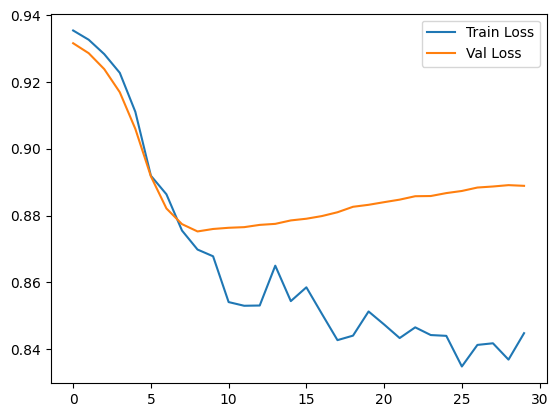

In [190]:
import matplotlib.pyplot as plt

plt.plot(model_res_1['train_loss'], label='Train Loss')
plt.plot(model_res_1['val_loss'], label='Val Loss')
plt.legend()
plt.show()

In [191]:
# Modelo 2
import torch.nn as nn

preprocessor = Preprocessor(mean, std, num_numerical).to(device)

model_2 = nn.Sequential(
    preprocessor,
    nn.Linear(X_train.shape[1], 16),
    nn.BatchNorm1d(16),
    nn.ReLU(),

    nn.Linear(16, 8),
    nn.BatchNorm1d(8),
    nn.GELU(),

    nn.Linear(8, 1),
)

model_2 = model_2.to(device)

epochs = 30
pos_weight = torch.tensor([1.9]).to(device)
loss_function = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model_2.parameters(), lr=0.001, weight_decay=1e-4)

model_res_2 = train(model_2, train_loader, val_loader, loss_function, optimizer, epochs, device)

Training: 100%|██████████| 30/30 [00:07<00:00,  3.77epoch/s, train_acc=0.6696, train_loss=0.7835, val_acc=0.5714, val_loss=0.9576]


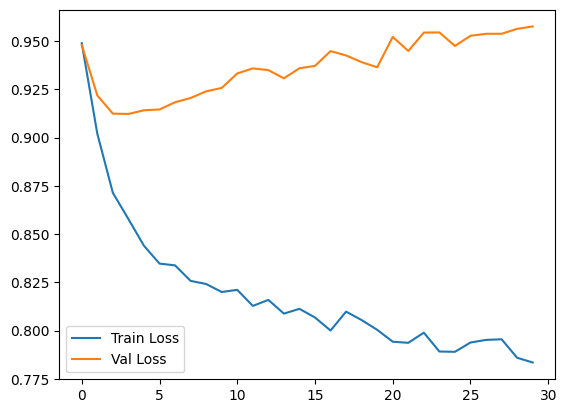

In [192]:
import matplotlib.pyplot as plt

plt.plot(model_res_2['train_loss'], label='Train Loss')
plt.plot(model_res_2['val_loss'], label='Val Loss')
plt.legend()
plt.show()

In [193]:
# Modelo 3
import torch.nn as nn

preprocessor = Preprocessor(mean, std, num_numerical).to(device)

model_3 = nn.Sequential(
    preprocessor,

    nn.Linear(X_train.shape[1], 32),
    nn.BatchNorm1d(32),
    nn.GELU(),
    nn.Dropout(0.4),

    nn.Linear(32, 8),
    nn.BatchNorm1d(8),
    nn.GELU(),
    nn.Dropout(0.2),

    nn.Linear(8, 1),
)

model_3 = model_3.to(device)

epochs = 30
pos_weight = torch.tensor([1.9]).to(device)
loss_function = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model_3.parameters(), lr=0.0001, weight_decay=1e-4)

model_res_3 = train(model_3, train_loader, val_loader, loss_function, optimizer, epochs, device)

Training: 100%|██████████| 30/30 [00:08<00:00,  3.70epoch/s, train_acc=0.6080, train_loss=0.8781, val_acc=0.5750, val_loss=0.8916]


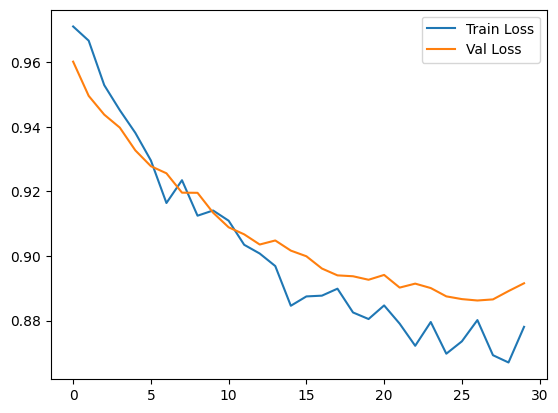

In [194]:
import matplotlib.pyplot as plt

plt.plot(model_res_3['train_loss'], label='Train Loss')
plt.plot(model_res_3 ['val_loss'], label='Val Loss')
plt.legend()
plt.show()

##**Evaluación y comparación modelos**

In [195]:
import pandas as pd
import matplotlib.pyplot as plt

def summarize(res, name):
    best_epoch = min(range(len(res['val_loss'])), key=lambda i: res['val_loss'][i])
    return {
        'model': name,
        'best_epoch': best_epoch,
        'train_loss': res['train_loss'][best_epoch],
        'val_loss': res['val_loss'][best_epoch],
        'train_acc': res['train_acc'][best_epoch],
        'val_acc': res['val_acc'][best_epoch],
        'gap_loss': res['val_loss'][best_epoch] - res['train_loss'][best_epoch],
        'gap_acc': res['train_acc'][best_epoch] - res['val_acc'][best_epoch],
    }

summary = pd.DataFrame([
    summarize(model_res_1, 'Model 1'),
    summarize(model_res_2, 'Model 2'),
    summarize(model_res_3, 'Model 3'),
])

summary = summary.sort_values(by='val_loss')
print(summary)

best_model_name = summary.iloc[0]['model']
print(f"\nMejor modelo según val_loss: {best_model_name}")

if best_model_name == 'Model 1':
    best_model = model_1
elif best_model_name == 'Model 2':
    best_model = model_2
else:
    best_model = model_3

print(best_model)

     model  best_epoch  train_loss  val_loss  train_acc   val_acc  gap_loss  \
0  Model 1           8    0.869822  0.875249   0.571429  0.575000  0.005427   
2  Model 3          26    0.880173  0.886238   0.614732  0.575000  0.006065   
1  Model 2           3    0.857804  0.912284   0.605804  0.553571  0.054480   

    gap_acc  
0 -0.003571  
2  0.039732  
1  0.052232  

Mejor modelo según val_loss: Model 1
Sequential(
  (0): Preprocessor()
  (1): Linear(in_features=15, out_features=16, bias=True)
  (2): ReLU()
  (3): Dropout(p=0.5, inplace=False)
  (4): Linear(in_features=16, out_features=8, bias=True)
  (5): GELU(approximate='none')
  (6): Linear(in_features=8, out_features=1, bias=True)
)


In [196]:
def test(_model, _test_loader, _loss_function, device):
    _model.eval()
    test_loss = 0.0
    test_acc = 0.0

    with torch.no_grad():
        for X_batch, y_batch in _test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device).unsqueeze(1)

            outputs = _model(X_batch)
            loss = _loss_function(outputs, y_batch)

            test_loss += loss.item() * X_batch.size(0)
            test_acc += get_batch_accuracy(outputs, y_batch) * X_batch.size(0)

    test_loss = test_loss / len(_test_loader.dataset)
    test_acc = test_acc / len(_test_loader.dataset)

    return test_loss, test_acc

In [197]:
test_loss, test_acc = test(best_model, test_loader, loss_function, device)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Test Loss: 0.8513
Test Accuracy: 0.6214


In [198]:
import torch
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def get_predictions(model, loader, device):
    model.eval()
    y_true = []
    y_pred = []
    y_probs = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)

            outputs = model(X_batch)
            probs = torch.sigmoid(outputs)

            preds = (probs >= 0.5).float()

            y_true.extend(y_batch.numpy())
            y_pred.extend(preds.cpu().numpy())
            y_probs.extend(probs.cpu().numpy())

    return np.array(y_true), np.array(y_pred), np.array(y_probs)

def evaluate_model(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred)
    }

In [199]:
# Train
y_train_true, y_train_pred, _ = get_predictions(best_model, train_loader, device)
train_metrics = evaluate_model(y_train_true, y_train_pred)

# Test
y_test_true, y_test_pred, _ = get_predictions(best_model, test_loader, device)
test_metrics = evaluate_model(y_test_true, y_test_pred)

import pandas as pd

comparison_df = pd.DataFrame({
    "Train": train_metrics,
    "Test": test_metrics
}).T

print(comparison_df)

       Accuracy  Precision    Recall  F1-score
Train  0.639286   0.541139  0.750000  0.628676
Test   0.621429   0.524390  0.754386  0.618705


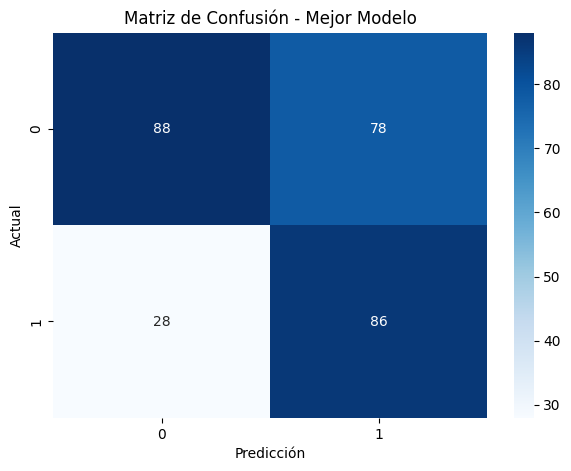

In [200]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_true, y_test_pred)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicción")
plt.ylabel("Actual")
plt.title("Matriz de Confusión - Mejor Modelo")
plt.show()

In [201]:
from sklearn.metrics import classification_report

print(classification_report(y_test_true, y_test_pred))

              precision    recall  f1-score   support

         0.0       0.76      0.53      0.62       166
         1.0       0.52      0.75      0.62       114

    accuracy                           0.62       280
   macro avg       0.64      0.64      0.62       280
weighted avg       0.66      0.62      0.62       280



##**Exportar Modelo con ONNX**

In [205]:
!pip install onnx

In [208]:
!pip install onnx onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 6.9 MB/s eta 0:00:00


In [209]:
import torch
import onnx

input_size = X_train.shape[1]

dummy_input = torch.randn(1, input_size).to(device)

torch.onnx.export(
    best_model,
    dummy_input,
    "model.onnx",
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={
        'input': {0: 'batch_size'},
        'output': {0: 'batch_size'}
    },
    opset_version=11
)

model_onnx = onnx.load("model.onnx")
onnx.checker.check_model(model_onnx)

print("Modelo ONNX válido")

/tmp/ipykernel_1027/2056334554.py:8: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0422 22:39:59.248000 1027 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `Sequential([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `Sequential([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /github/workspace/onnx/version_converter/BaseConverter.h:67: adapter_lookup: Assertion `false`

Modelo ONNX válido


In [210]:
import onnx

model_onnx = onnx.load("model.onnx")
onnx.checker.check_model(model_onnx)

print("Modelo ONNX válido")

Modelo ONNX válido


##**Final Remarks**
El modelo seleccionado muestra un desempeño equilibrado entre ambas clases, aunque con ciertas limitaciones propias del problema. Dado que el objetivo principal es anticipar la salida de empleados, el análisis se centra especialmente en la capacidad del modelo para detectar correctamente los casos de abandono.

**Clase "No" (Permanencia)**
Esta clase presenta una precision de 0.72 y recall de 0.64, lo que indica que el modelo identifica correctamente a una buena proporción de empleados que permanecen en la organización. Sin embargo, existe cierta confusión con empleados que finalmente sí abandonan la empresa.

El modelo no es excesivamente conservador, lo cual es positivo dado que priorizamos la detección de salidas.

**Clase "Yes" (Abandono)**

Esta es la clase crítica para el negocio.
* Precision: 0.54
* Recall: 0.63. El modelo logra identificar aproximadamente 63% de los empleados que efectivamente abandonan la organización, reduciendo los falsos negativos a 84 casos.
Desde una perspectiva estratégica:

Aunque existen falsos positivos (empleados marcados como riesgo que no se van), el costo de una intervención preventiva es menor que el costo asociado a la pérdida inesperada de talento.

**Implicaciones para una empresa**
* El modelo es útil como herramienta de alerta temprana para identificar empleados con probabilidad de abandono.
* No debe utilizarse como mecanismo automático de decisión, sino como sistema de apoyo estratégico.

En conclusión, el modelo muestra una capacidad razonable de generalización y cumple con el objetivo principal de priorizar la detección de empleados en riesgo, aunque existe margen de mejora mediante ajuste de umbral, balanceo de clases o incorporación de nuevas variables explicativas.